In [ ]:
pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [ ]:
%matplotlib inline


In [ ]:
print(tf.__version__)

2.19.0


In [ ]:
# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Convert labels to categorical format (One-hot encoding)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
# Define the CNN model
model = Sequential()

# First Convolutional Layer
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPooling2D((2, 2)))

# Second Convolutional Layer
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Flatten the output to feed into fully connected layers
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(64, activation='relu'))

# Dropout Layer to avoid overfitting
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Summary of the model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.2549 - loss: 1.9758 - val_accuracy: 0.4976 - val_loss: 1.4104
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4325 - loss: 1.5434 - val_accuracy: 0.5712 - val_loss: 1.2337
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4812 - loss: 1.4107 - val_accuracy: 0.5942 - val_loss: 1.1565
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5204 - loss: 1.3199 - val_accuracy: 0.6187 - val_loss: 1.1139
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5433 - loss: 1.2640 - val_accuracy: 0.6329 - val_loss: 1.0614
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.5716 - loss: 1.1965 - val_accuracy: 0.6463 - val_loss: 1.0207
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5954 - loss: 1.1454 - val_accuracy: 0.6538 - val_loss: 1.0088
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6027 - loss: 1.1084 

In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=2)
print(f'Test accuracy: {test_accuracy:.2f}')

313/313 - 1s - 2ms/step - accuracy: 0.6970 - loss: 0.9008
Test accuracy: 0.70


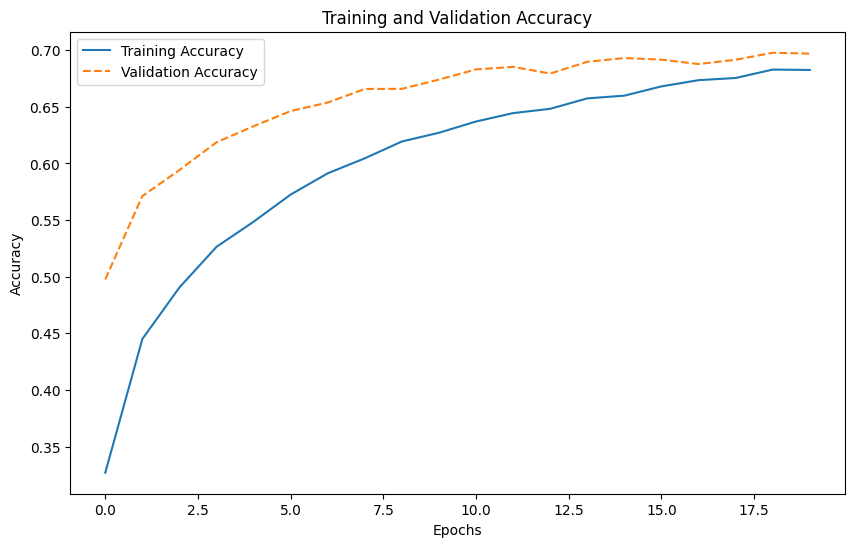

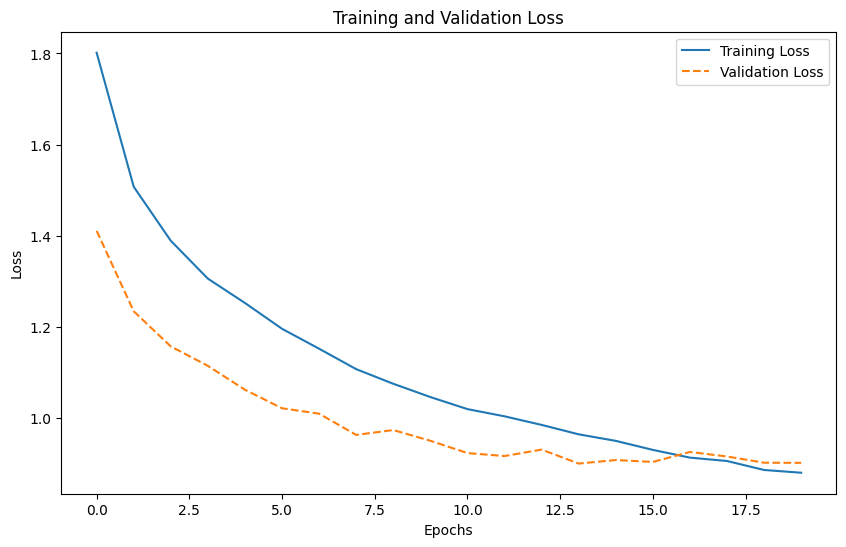

In [ ]:
# Convert the history to a DataFrame for easy visualization
import pandas as pd
history_df = pd.DataFrame(history.history)

# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history_df['accuracy'], label='Training Accuracy')
plt.plot(history_df['val_accuracy'], linestyle='--', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], linestyle='--', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

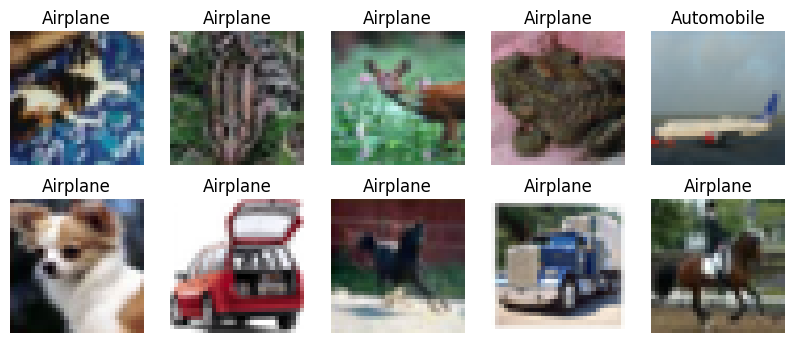

In [ ]:
import numpy as np

class_names = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

plt.figure(figsize=(10, 4))

indices = np.random.choice(len(X_train), 10)

for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx])
    plt.title(class_names[int(y_train[idx][0])])  # ✅ FIX
    plt.axis("off")


Downloading/Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Starting Experiments...

EXPERIMENT SUMMARY TABLE
          Config Output Dim  Params  Time (s)  Accuracy
Valid | Stride 1      26x26   54410      5.28    0.9669
Same  | Stride 1      28x28   63050      5.41    0.9670
Valid | Stride 2      13x13   11850      3.89    0.9417
Same  | Stride 2      14x14   16010      4.79    0.9440


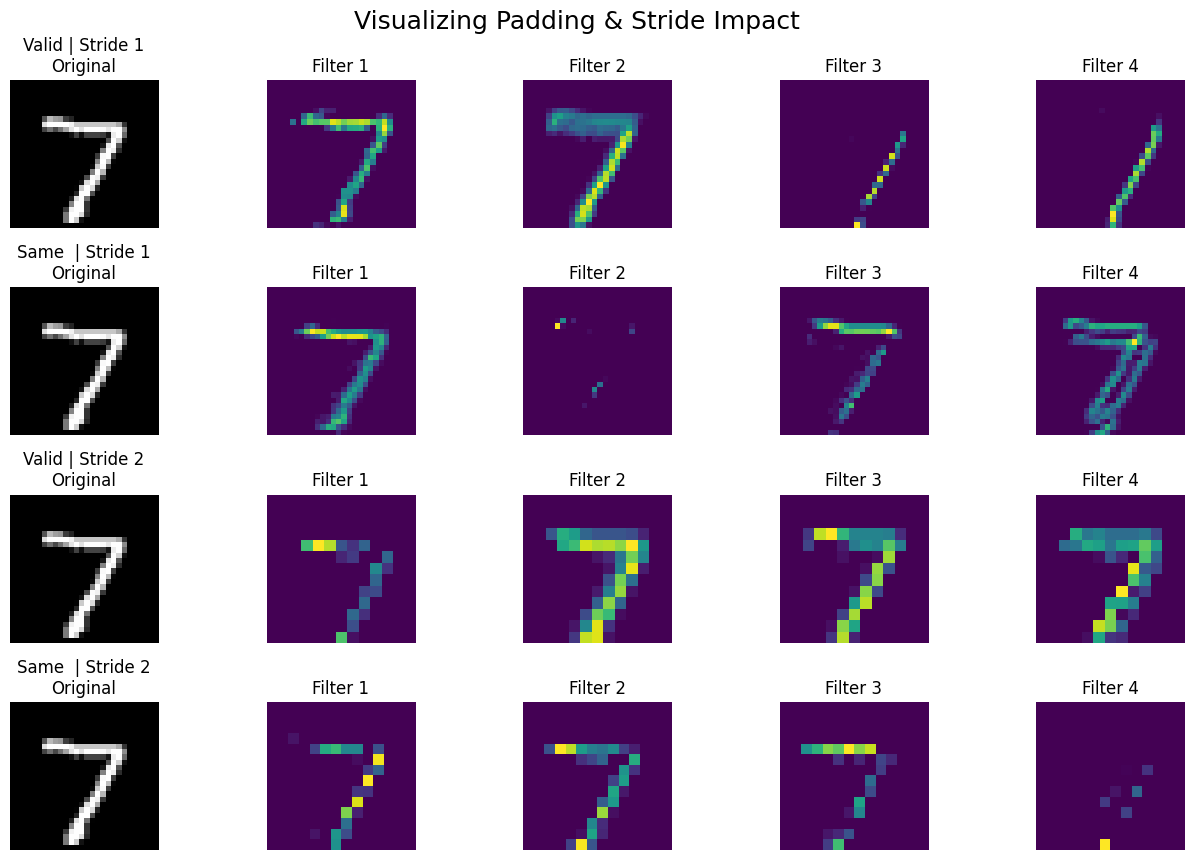

In [1]:


"""
CNN Padding and Stride Impact Visualizer
========================================
This script demonstrates the architectural and performance impacts of
different padding ('valid' vs. 'same') and stride (1 vs. 2) configurations
in Convolutional Neural Networks (CNNs).

It uses the MNIST dataset to dynamically generate:
1. A performance summary table (Parameter counts, Training Time, Accuracy).
2. A Matplotlib dashboard visualizing the spatial effects on feature maps.

Usage:
    Run the script directly from the terminal:
    $ python cnn_experiment.py

Dependencies:
    tensorflow, numpy, matplotlib, pandas
"""

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

def run_experiments():
    """Main function to load data, iterate through CNN configs, and plot results."""

    # ---------------------------------------------------------
    # 1. LOAD AND PREPROCESS DATA
    # ---------------------------------------------------------
    print("Downloading/Loading MNIST dataset...")
    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

    # Reshape to include the channel dimension (grayscale = 1) and normalize to [0, 1]
    x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
    x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

    # One-hot encode the target labels (0-9)
    y_train = keras.utils.to_categorical(y_train, 10)
    y_test = keras.utils.to_categorical(y_test, 10)

    # ---------------------------------------------------------
    # 2. DEFINE EXPERIMENT CONFIGURATIONS
    # ---------------------------------------------------------
    # We test four combinations to see how spatial downsampling and
    # boundary handling affect the network's geometry.
    configs = [
        {"padding": "valid", "stride": 1, "name": "Valid | Stride 1"},
        {"padding": "same",  "stride": 1, "name": "Same  | Stride 1"},
        {"padding": "valid", "stride": 2, "name": "Valid | Stride 2"},
        {"padding": "same",  "stride": 2, "name": "Same  | Stride 2"}
    ]

    results = []
    feature_maps_to_plot = []

    # Isolate a single test image to visualize the filter activations
    sample_digit = x_test[0:1]

    print("\nStarting Experiments...")
    for config in configs:
        # --- Build Model Architecture ---
        inputs = layers.Input(shape=(28, 28, 1))

        # Target Convolutional Layer where we apply our hyperparameter tests
        conv_layer = layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            padding=config['padding'],
            strides=config['stride'],
            activation='relu',
            name='target_conv'
        )(inputs)

        # Create an intermediate model specifically to extract the visual feature maps
        intermediate_model = keras.Model(inputs=inputs, outputs=conv_layer)

        # Complete the model for actual training
        x = layers.MaxPooling2D((2, 2))(conv_layer)
        x = layers.Flatten()(x)
        outputs = layers.Dense(10, activation='softmax')(x)
        model = keras.Model(inputs=inputs, outputs=outputs)

        # --- Extract Geometry and Metrics ---
        # Predict on the sample digit to get the spatial dimensions of the feature map
        maps = intermediate_model.predict(sample_digit, verbose=0)
        out_shape = maps.shape[1:3]
        params = model.count_params()

        # --- Train and Benchmark ---
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        start = time.time()
        # Brief training (2 epochs) just to measure time and base accuracy
        model.fit(x_train, y_train, epochs=2, batch_size=256, verbose=0)
        train_time = round(time.time() - start, 2)

        _, acc = model.evaluate(x_test, y_test, verbose=0)

        # --- Store Results ---
        results.append({
            "Config": config['name'],
            "Output Dim": f"{out_shape[0]}x{out_shape[1]}",
            "Params": params,
            "Time (s)": train_time,
            "Accuracy": round(acc, 4)
        })
        feature_maps_to_plot.append((maps, config['name']))

    # ---------------------------------------------------------
    # 3. CONSOLE SUMMARY OUTPUT
    # ---------------------------------------------------------
    print("\n" + "="*60)
    print("EXPERIMENT SUMMARY TABLE")
    print("="*60)
    # Pandas provides a clean, readable ASCII table for the console
    print(pd.DataFrame(results).to_string(index=False))

    # ---------------------------------------------------------
    # 4. MATPLOTLIB VISUALIZATION DASHBOARD
    # ---------------------------------------------------------
    fig, axes = plt.subplots(4, 5, figsize=(16, 10))
    plt.subplots_adjust(hspace=0.4)

    for i, (maps, name) in enumerate(feature_maps_to_plot):
        # Column 0: Show the Original Image
        axes[i, 0].imshow(sample_digit[0, :, :, 0], cmap='gray')
        axes[i, 0].set_title(f"{name}\nOriginal")
        axes[i, 0].axis('off')

        # Columns 1-4: Show the first 4 filter activations
        for j in range(1, 5):
            axes[i, j].imshow(maps[0, :, :, j], cmap='viridis')
            axes[i, j].set_title(f"Filter {j}")
            axes[i, j].axis('off')

    plt.suptitle("Visualizing Padding & Stride Impact", fontsize=18, y=0.95)
    plt.show()

if __name__ == "__main__":
    run_experiments()